<a href="https://colab.research.google.com/github/np03cs4a230349-stack/AI-ML/blob/main/2408983_Abhiral_Pradhan_code_PartA_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
import os

SOURCE_FOLDER = "/content/drive/MyDrive/AI-ML/Portfolio/facial expression classification"
DEST_FOLDER = "/content/facial_expression_dataset"

# Remove old copied folder if it already exists
if os.path.exists(DEST_FOLDER):
    shutil.rmtree(DEST_FOLDER)

# Copy folder from Drive to /content
shutil.copytree(SOURCE_FOLDER, DEST_FOLDER)

print("Folder copied successfully!")
print("Copied to:", DEST_FOLDER)
print("Folders inside:", os.listdir(DEST_FOLDER))

Folder copied successfully!
Copied to: /content/facial_expression_dataset
Folders inside: ['validation', 'train', 'test']


In [ ]:
train_dir = "/content/facial_expression_dataset/train"

In [ ]:
class_counts = {}

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

class_counts

{'fear': 3796,
 'neutral': 4675,
 'disgust': 329,
 'surprise': 2898,
 'happy': 6857,
 'sad': 4631,
 'angry': 3686}

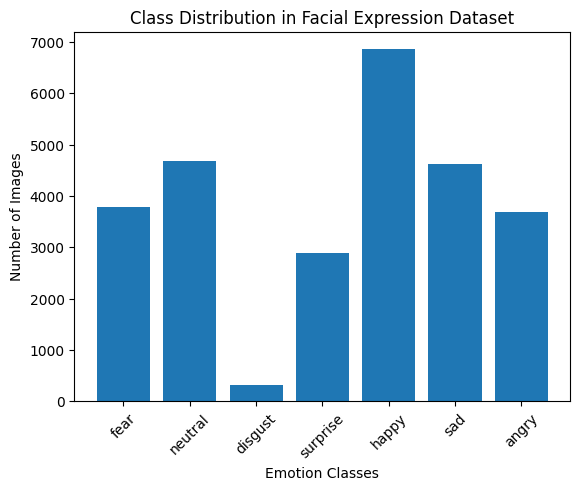

In [ ]:
plt.figure()
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Emotion Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution in Facial Expression Dataset")
plt.xticks(rotation=45)
plt.show()

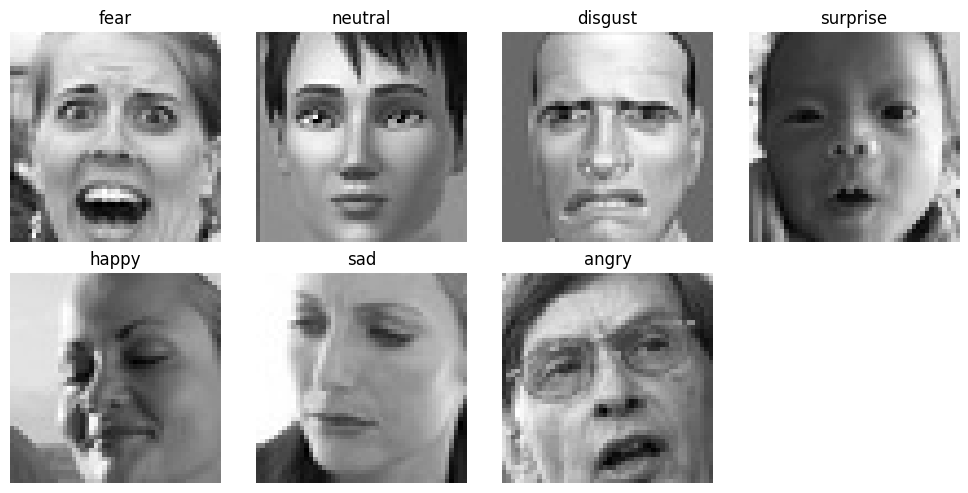

In [ ]:
plt.figure(figsize=(10,5))

for i, class_name in enumerate(class_counts.keys()):
    class_path = os.path.join(train_dir, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, 4, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image
import os


corrupted_per_class = {}

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        corrupted_count = 0

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                img = Image.open(img_path)
                img.verify()
            except:
                corrupted_count += 1

        corrupted_per_class[class_name] = corrupted_count

# Print results
for cls, count in corrupted_per_class.items():
    print(f"{cls}: {count} corrupted images")

fear: 0 corrupted images
neutral: 0 corrupted images
disgust: 0 corrupted images
surprise: 0 corrupted images
happy: 0 corrupted images
sad: 0 corrupted images
angry: 0 corrupted images


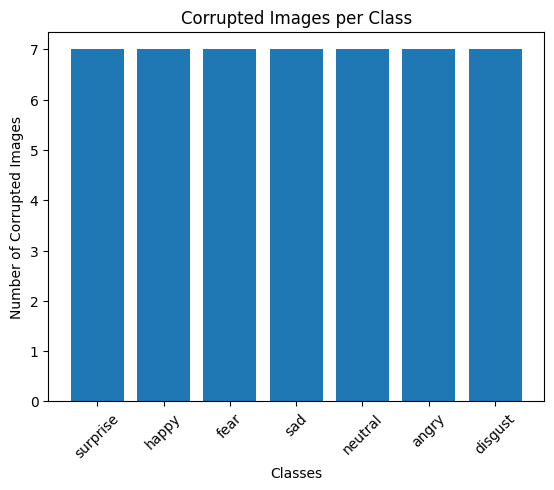

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(corrupted_per_class.keys(), corrupted_per_class.values())
plt.xlabel("Classes")
plt.ylabel("Number of Corrupted Images")
plt.title("Corrupted Images per Class")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Remove corrupted images

removed_images = 0

for class_name in os.listdir(train_dir):

    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):

        for img_name in os.listdir(class_path):

            img_path = os.path.join(class_path, img_name)

            try:
                img = Image.open(img_path)
                img.verify()

            except:
                os.remove(img_path)
                removed_images += 1

print(f"Total corrupted images removed: {removed_images}")

Total corrupted images removed: 49


In [ ]:
# Updated class counts after cleaning

updated_class_counts = {}

for class_name in os.listdir(train_dir):

    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):

        updated_class_counts[class_name] = len(os.listdir(class_path))

updated_class_counts

{'fear': 3796,
 'neutral': 4675,
 'disgust': 329,
 'surprise': 2898,
 'happy': 6857,
 'sad': 4631,
 'angry': 3686}

preprocessing and data augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
IMG_SIZE = 64
BATCH_SIZE = 32

In [ ]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=10,

    width_shift_range=0.1,

    height_shift_range=0.1,

    zoom_range=0.1,

    horizontal_flip=True
)

not data augmentaion for test and validation

In [ ]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
val_dir = "/content/facial_expression_dataset/validation"

test_dir = "/content/facial_expression_dataset/test"

In [ ]:
train_generator = train_datagen.flow_from_directory(

    train_dir,

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    color_mode='grayscale'
)

Found 26872 images belonging to 7 classes.


In [ ]:
validation_generator = test_datagen.flow_from_directory(

    val_dir,

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    color_mode='grayscale'
)

Found 7066 images belonging to 7 classes.


In [ ]:
test_generator = test_datagen.flow_from_directory(

    test_dir,

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    color_mode='grayscale',

    shuffle=False
)

Found 1900 images belonging to 7 classes.


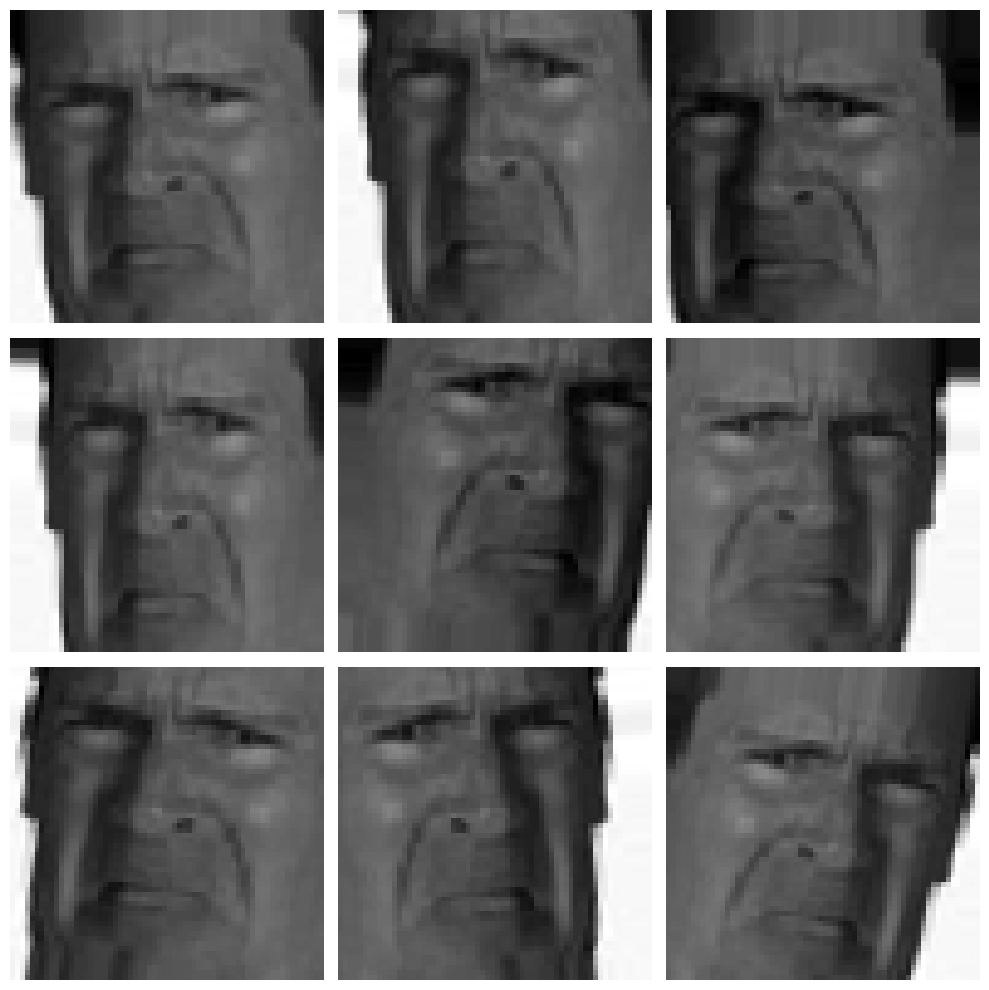

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

sample_class = random.choice(os.listdir(train_dir))

sample_image = random.choice(
    os.listdir(os.path.join(train_dir, sample_class))
)

sample_image_path = os.path.join(
    train_dir,
    sample_class,
    sample_image
)

img = load_img(
    sample_image_path,
    color_mode='grayscale',
    target_size=(64,64)
)

x = img_to_array(img)

x = x.reshape((1,) + x.shape)

plt.figure(figsize=(10,10))

i = 0

for batch in train_datagen.flow(x, batch_size=1):

    plt.subplot(3,3,i+1)

    plt.imshow(batch[0].reshape(64,64), cmap='gray')

    plt.axis('off')

    i += 1

    if i == 9:
        break

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

Baseline model

In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (

    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

baseline_model = Sequential()

# Block 1
baseline_model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(64,64,1)
    )
)

baseline_model.add(BatchNormalization())

baseline_model.add(MaxPooling2D((2,2)))

# Block 2
baseline_model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    )
)

baseline_model.add(BatchNormalization())

baseline_model.add(MaxPooling2D((2,2)))

# Block 3
baseline_model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    )
)

baseline_model.add(BatchNormalization())

baseline_model.add(MaxPooling2D((2,2)))

# Flatten
baseline_model.add(Flatten())

# FC Layers
baseline_model.add(Dense(256, activation='relu'))

baseline_model.add(Dropout(0.5))

baseline_model.add(Dense(128, activation='relu'))

baseline_model.add(Dropout(0.3))

baseline_model.add(Dense(64, activation='relu'))

# Output
baseline_model.add(Dense(7, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0001)

baseline_model.compile(

    optimizer=optimizer,

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [ ]:
baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,232,583 (8.52 MB)

 Trainable params: 2,232,135 (8.51 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
history = baseline_model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=20,

)

Epoch 1/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 43s 43ms/step - accuracy: 0.2386 - loss: 1.8736 - val_accuracy: 0.3231 - val_loss: 1.7263
Epoch 2/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.2661 - loss: 1.7752 - val_accuracy: 0.3398 - val_loss: 1.6863
Epoch 3/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.2995 - loss: 1.7246 - val_accuracy: 0.3786 - val_loss: 1.5988
Epoch 4/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.3301 - loss: 1.6732 - val_accuracy: 0.4063 - val_loss: 1.5279
Epoch 5/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.3506 - loss: 1.6359 - val_accuracy: 0.4273 - val_loss: 1.5225
Epoch 6/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.3727 - loss: 1.5979 - val_accuracy: 0.4298 - val_loss: 1.4577
Epoch 7/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.3847 - loss: 1.5668 - val_accuracy: 0.4519 - val_loss: 1.4212
Epoch 8/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.3947 - loss: 1.5357 - 

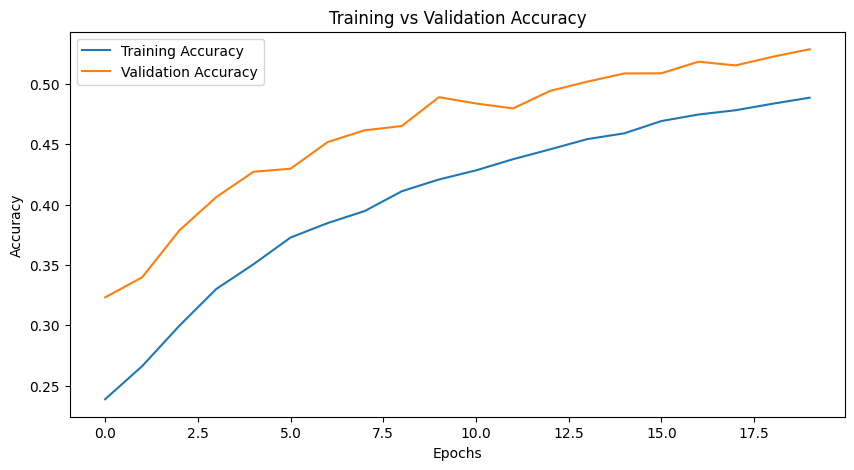

In [ ]:

plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.title('Training vs Validation Accuracy')

plt.legend()

plt.show()

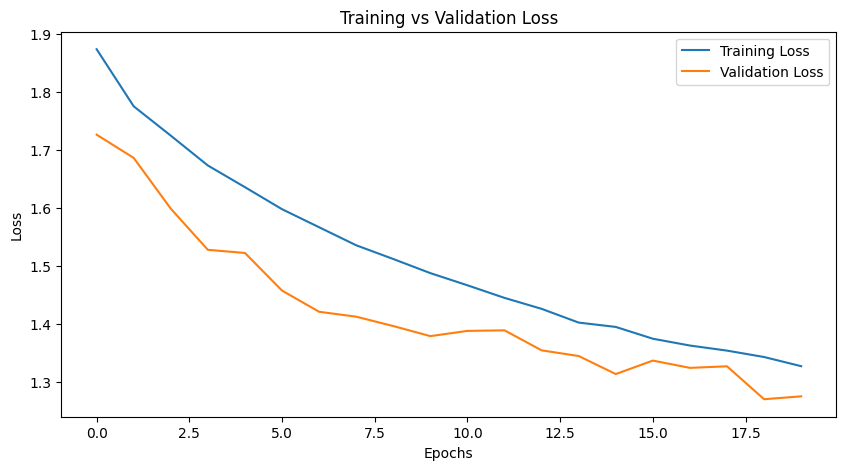

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')

plt.ylabel('Loss')

plt.title('Training vs Validation Loss')

plt.legend()

plt.show()

In [ ]:
import numpy as np

predictions = baseline_model.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)

60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step


In [ ]:
true_classes = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

In [ ]:
from sklearn.metrics import classification_report

print(

    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_labels
    )
)

              precision    recall  f1-score   support

       angry       0.38      0.42      0.40       300
     disgust       0.00      0.00      0.00       100
        fear       0.28      0.11      0.16       300
       happy       0.58      0.82      0.68       300
     neutral       0.42      0.60      0.49       300
         sad       0.31      0.36      0.33       300
    surprise       0.75      0.60      0.67       300

    accuracy                           0.46      1900
   macro avg       0.39      0.42      0.39      1900
weighted avg       0.43      0.46      0.43      1900



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


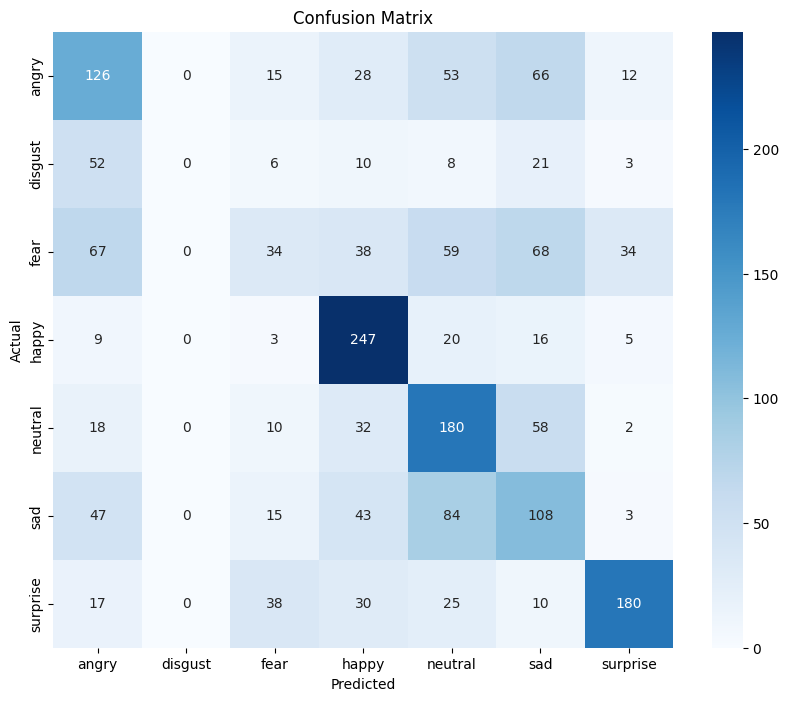

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()

In [ ]:
sample_batch = next(test_generator)

images, labels = sample_batch

preds = baseline_model.predict(images)

pred_classes = np.argmax(preds, axis=1)

true_classes = np.argmax(labels, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step


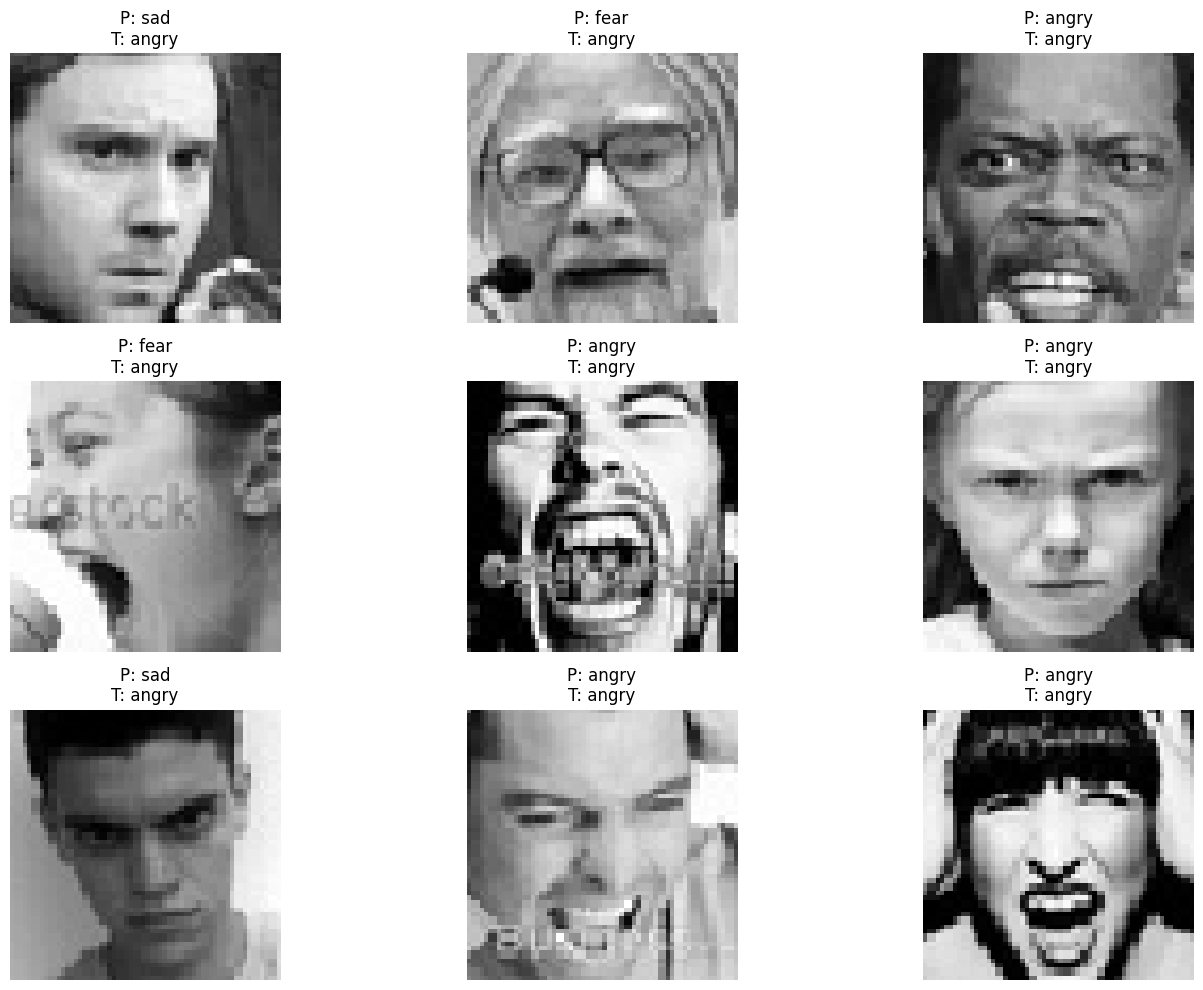

In [ ]:
plt.figure(figsize=(15,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i].reshape(64,64), cmap='gray')

    pred_label = class_labels[pred_classes[i]]

    true_label = class_labels[true_classes[i]]

    plt.title(f"P: {pred_label}\nT: {true_label}")

    plt.axis('off')

plt.tight_layout()

plt.show()

Deeper Architecture with Regularization Layer:

In [ ]:
import tensorflow as tf

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (

    Conv2D,
    MaxPooling2D,

    Flatten,

    Dense,

    Dropout,

    BatchNormalization
)

from tensorflow.keras.optimizers import Adam, SGD

from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
deep_model = Sequential()

# BLOCK 1

deep_model.add(

    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(64,64,1)
    )
)

deep_model.add(BatchNormalization())

deep_model.add(

    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same'
    )
)

deep_model.add(MaxPooling2D((2,2)))

deep_model.add(Dropout(0.25))

# BLOCK 2

deep_model.add(

    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    )
)

deep_model.add(BatchNormalization())

deep_model.add(

    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    )
)

deep_model.add(MaxPooling2D((2,2)))

deep_model.add(Dropout(0.25))

# BLOCK 3

deep_model.add(

    Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    )
)

deep_model.add(BatchNormalization())

deep_model.add(

    Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    )
)

deep_model.add(MaxPooling2D((2,2)))

deep_model.add(Dropout(0.3))

# CLASSIFIER

deep_model.add(Flatten())

deep_model.add(Dense(256, activation='relu'))

deep_model.add(Dropout(0.5))

deep_model.add(Dense(128, activation='relu'))

deep_model.add(Dropout(0.3))

deep_model.add(Dense(7, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
deep_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,418,535 (9.23 MB)

 Trainable params: 2,418,087 (9.22 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
adam_optimizer = Adam(learning_rate=0.0001)

deep_model.compile(

    optimizer=adam_optimizer,

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [ ]:
early_stopping = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

In [ ]:
import time

start_time = time.time()

deep_history_adam = deep_model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=30,

    callbacks=[early_stopping]
)

end_time = time.time()

adam_training_time = end_time - start_time

print("Total Training Time:", adam_training_time, "seconds")

Epoch 1/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 57s 51ms/step - accuracy: 0.2139 - loss: 1.9004 - val_accuracy: 0.2584 - val_loss: 1.8038
Epoch 2/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.2411 - loss: 1.8336 - val_accuracy: 0.2581 - val_loss: 1.7963
Epoch 3/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.2465 - loss: 1.8122 - val_accuracy: 0.2583 - val_loss: 1.7692
Epoch 4/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.2516 - loss: 1.7969 - val_accuracy: 0.2583 - val_loss: 1.7604
Epoch 5/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 32s 38ms/step - accuracy: 0.2541 - loss: 1.7677 - val_accuracy: 0.2639 - val_loss: 1.6953
Epoch 6/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.2593 - loss: 1.7393 - val_accuracy: 0.3034 - val_loss: 1.6655
Epoch 7/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 32s 38ms/step - accuracy: 0.2800 - loss: 1.7041 - val_accuracy: 0.3491 - val_loss: 1.6218
Epoch 8/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 32s 38ms/step - accuracy: 0.3012 - loss: 1.6797 - 

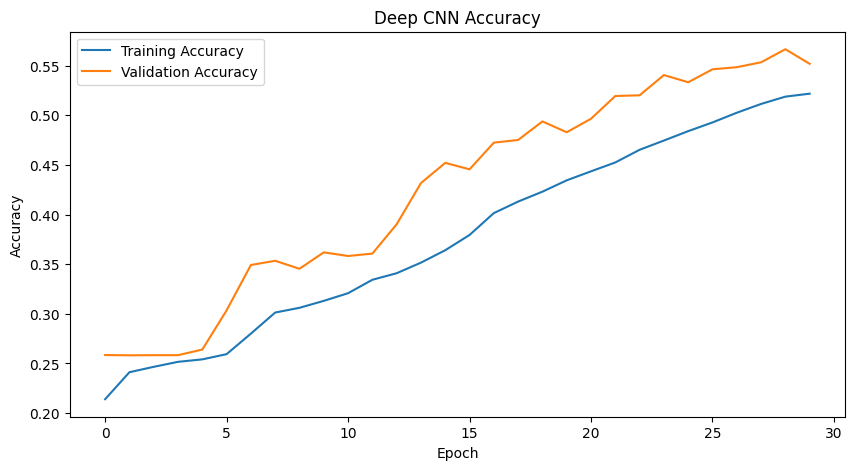

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    deep_history_adam.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    deep_history_adam.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.title('Deep CNN Accuracy')

plt.legend()

plt.show()

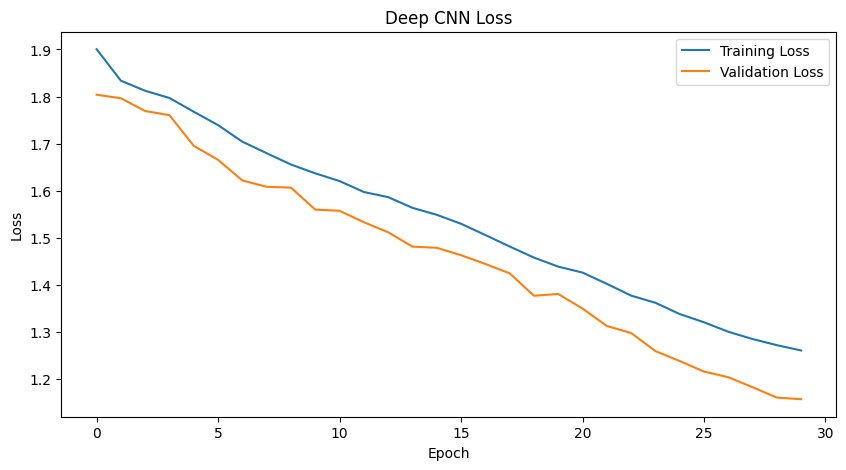

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    deep_history_adam.history['loss'],
    label='Training Loss'
)

plt.plot(
    deep_history_adam.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Deep CNN Loss')

plt.legend()

plt.show()

In [ ]:
test_loss, test_accuracy = deep_model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)

print("Test Loss:", test_loss)

60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.4942 - loss: 1.3608
Test Accuracy: 0.49421051144599915
Test Loss: 1.3608191013336182


In [ ]:
predictions = deep_model.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

print(

    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_labels
    )
)

60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step
              precision    recall  f1-score   support

       angry       0.46      0.34      0.39       300
     disgust       0.00      0.00      0.00       100
        fear       0.40      0.08      0.14       300
       happy       0.56      0.88      0.68       300
     neutral       0.39      0.74      0.51       300
         sad       0.40      0.33      0.36       300
    surprise       0.69      0.75      0.72       300

    accuracy                           0.49      1900
   macro avg       0.41      0.45      0.40      1900
weighted avg       0.46      0.49      0.44      1900



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


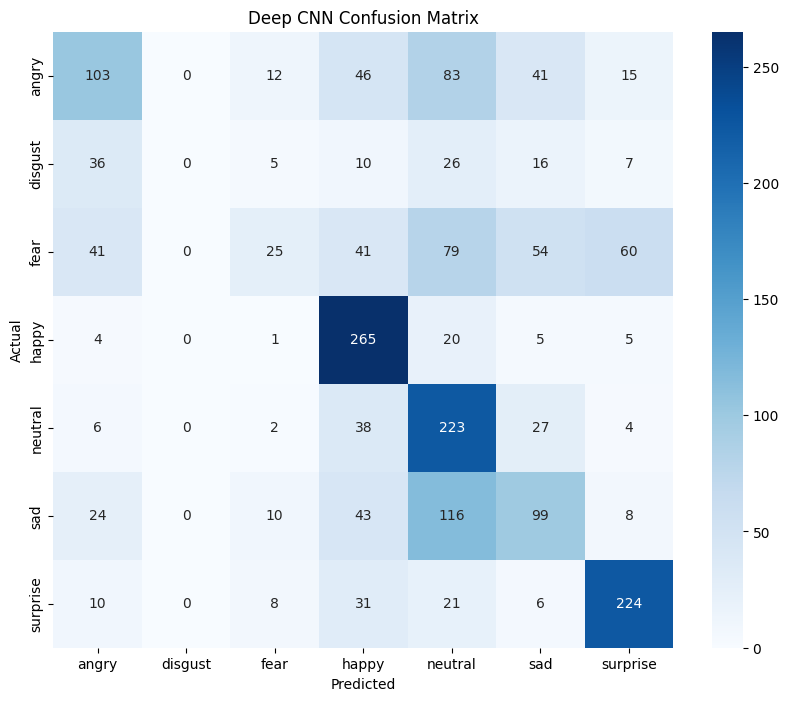

In [ ]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=class_labels,

    yticklabels=class_labels
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.title('Deep CNN Confusion Matrix')

plt.show()

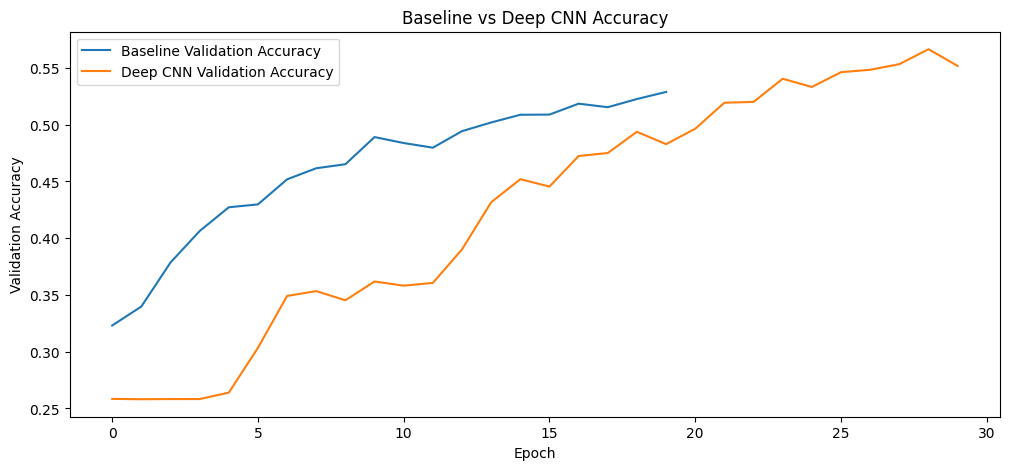

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    history.history['val_accuracy'],
    label='Baseline Validation Accuracy'
)

plt.plot(
    deep_history_adam.history['val_accuracy'],
    label='Deep CNN Validation Accuracy'
)

plt.xlabel('Epoch')

plt.ylabel('Validation Accuracy')

plt.title('Baseline vs Deep CNN Accuracy')

plt.legend()

plt.show()

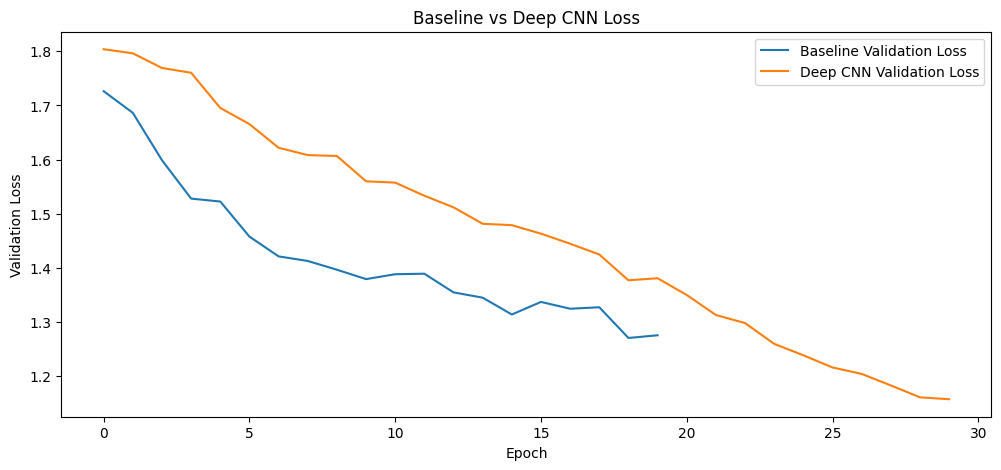

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    history.history['val_loss'],
    label='Baseline Validation Loss'
)

plt.plot(
    deep_history_adam.history['val_loss'],
    label='Deep CNN Validation Loss'
)

plt.xlabel('Epoch')

plt.ylabel('Validation Loss')

plt.title('Baseline vs Deep CNN Loss')

plt.legend()

plt.show()

In [ ]:
sgd_optimizer = SGD(

    learning_rate=0.001,

    momentum=0.9
)

deep_model.compile(

    optimizer=sgd_optimizer,

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [ ]:
deep_history_sgd = deep_model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=30,

    callbacks=[early_stopping]
)

Epoch 1/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 52s 49ms/step - accuracy: 0.5049 - loss: 1.3008 - val_accuracy: 0.5008 - val_loss: 1.3739
Epoch 2/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 32s 38ms/step - accuracy: 0.5241 - loss: 1.2640 - val_accuracy: 0.5127 - val_loss: 1.2974
Epoch 3/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 32s 38ms/step - accuracy: 0.5327 - loss: 1.2437 - val_accuracy: 0.5596 - val_loss: 1.1608
Epoch 4/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.5325 - loss: 1.2367 - val_accuracy: 0.5679 - val_loss: 1.1459
Epoch 5/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.5393 - loss: 1.2221 - val_accuracy: 0.4874 - val_loss: 1.3556
Epoch 6/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.5425 - loss: 1.2139 - val_accuracy: 0.5505 - val_loss: 1.2191
Epoch 7/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.5455 - loss: 1.2050 - val_accuracy: 0.5784 - val_loss: 1.1239
Epoch 8/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.5498 - loss: 1.2027 - 

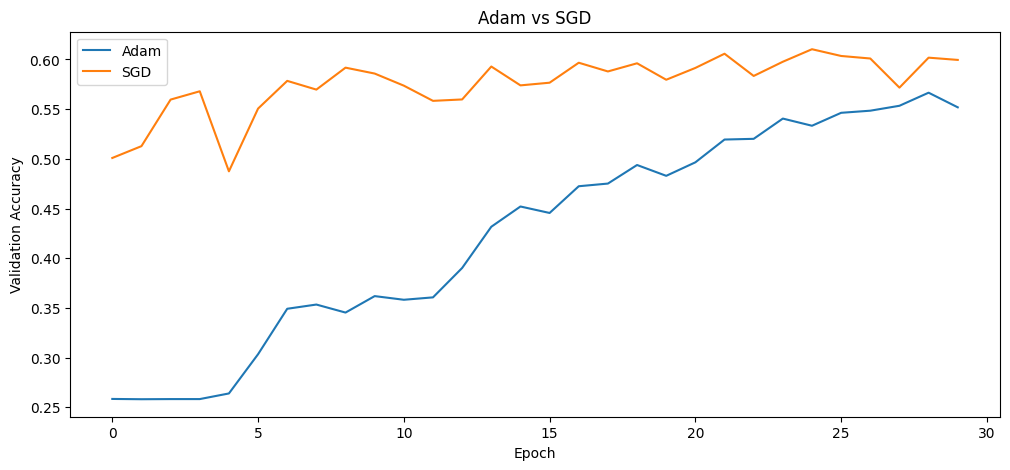

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    deep_history_adam.history['val_accuracy'],
    label='Adam'
)

plt.plot(
    deep_history_sgd.history['val_accuracy'],
    label='SGD'
)

plt.xlabel('Epoch')

plt.ylabel('Validation Accuracy')

plt.title('Adam vs SGD')

plt.legend()

plt.show()

Ablation Study:
• Remove one component (e.g., dropout or batch normalization).
• Analyze how performance changes.

In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (

    Conv2D,
    MaxPooling2D,

    Flatten,

    Dense,

    BatchNormalization
)

ablation_model = Sequential()

# BLOCK 1

ablation_model.add(

    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(64,64,1)
    )
)

ablation_model.add(BatchNormalization())

ablation_model.add(

    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same'
    )
)

ablation_model.add(MaxPooling2D((2,2)))

# BLOCK 2

ablation_model.add(

    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    )
)

ablation_model.add(BatchNormalization())

ablation_model.add(

    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    )
)

ablation_model.add(MaxPooling2D((2,2)))

# BLOCK 3

ablation_model.add(

    Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    )
)

ablation_model.add(BatchNormalization())

ablation_model.add(

    Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    )
)

ablation_model.add(MaxPooling2D((2,2)))

# CLASSIFIER

ablation_model.add(Flatten())

ablation_model.add(Dense(256, activation='relu'))

ablation_model.add(Dense(128, activation='relu'))

ablation_model.add(Dense(7, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from tensorflow.keras.optimizers import Adam

ablation_model.compile(

    optimizer=Adam(learning_rate=0.0001),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [ ]:
ablation_history = ablation_model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=15
)

Epoch 1/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 45s 44ms/step - accuracy: 0.3155 - loss: 1.7067 - val_accuracy: 0.3977 - val_loss: 1.5567
Epoch 2/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.3957 - loss: 1.5449 - val_accuracy: 0.4666 - val_loss: 1.3837
Epoch 3/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 32s 38ms/step - accuracy: 0.4511 - loss: 1.4189 - val_accuracy: 0.4802 - val_loss: 1.3492
Epoch 4/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 32s 38ms/step - accuracy: 0.4874 - loss: 1.3294 - val_accuracy: 0.5188 - val_loss: 1.2635
Epoch 5/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 32s 38ms/step - accuracy: 0.5167 - loss: 1.2649 - val_accuracy: 0.5425 - val_loss: 1.1915
Epoch 6/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.5311 - loss: 1.2196 - val_accuracy: 0.5367 - val_loss: 1.1967
Epoch 7/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.5512 - loss: 1.1795 - val_accuracy: 0.5668 - val_loss: 1.1431
Epoch 8/15
840/840 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.5618 - loss: 1.1522 - 

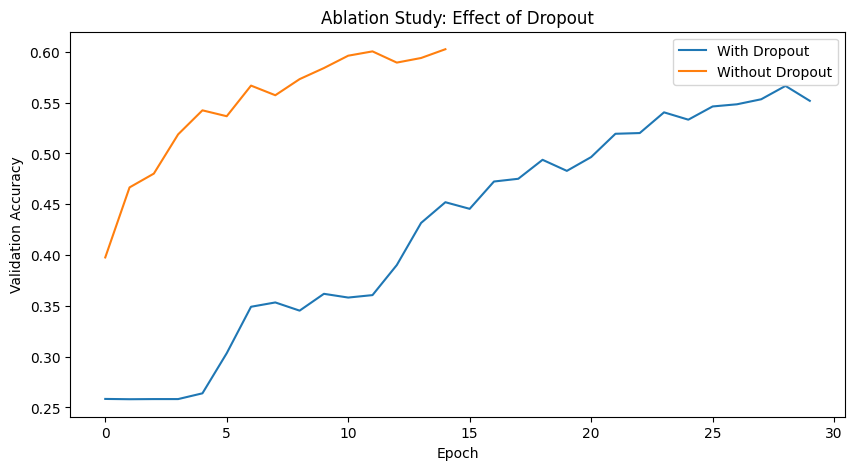

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    deep_history_adam.history['val_accuracy'],
    label='With Dropout'
)

plt.plot(
    ablation_history.history['val_accuracy'],
    label='Without Dropout'
)

plt.xlabel('Epoch')

plt.ylabel('Validation Accuracy')

plt.title('Ablation Study: Effect of Dropout')

plt.legend()

plt.show()

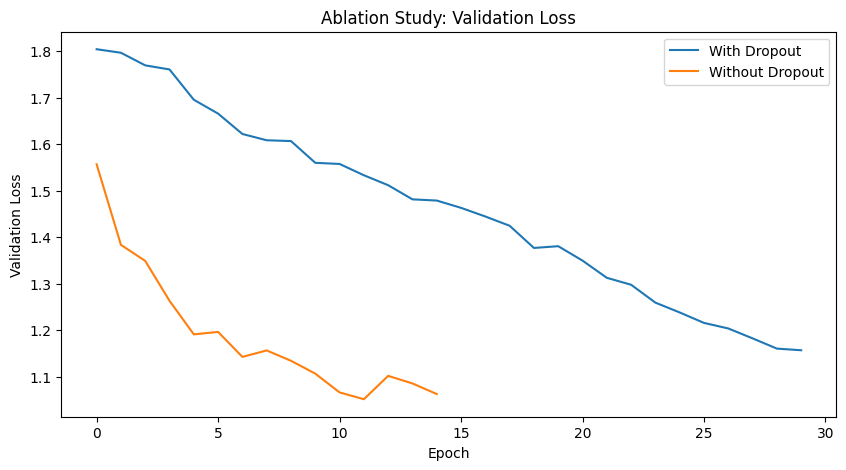

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    deep_history_adam.history['val_loss'],
    label='With Dropout'
)

plt.plot(
    ablation_history.history['val_loss'],
    label='Without Dropout'
)

plt.xlabel('Epoch')

plt.ylabel('Validation Loss')

plt.title('Ablation Study: Validation Loss')

plt.legend()

plt.show()